# Customer Retention & Churn Analysis

## Exploratory Data Analysis (EDA) – Churn Analysis

### Objective

The purpose of this notebook is to identify the key drivers of customer churn and understand which customer segments are most likely to discontinue services.

Customer churn directly impacts revenue, customer lifetime value, and long-term business growth. By analyzing churn behavior across different customer segments, the business can develop targeted retention strategies and reduce customer attrition.

### Business Goals

- Identify the characteristics of churned customers.
- Determine which customer segments have the highest churn rates.
- Evaluate the relationship between churn and customer demographics.
- Analyze churn across contract types, internet services, tenure groups, and pricing levels.
- Identify high-risk customer segments requiring retention initiatives.
- Generate actionable recommendations to improve customer retention.

### Key Business Questions

1. What is the overall churn rate?
2. Which customer segments churn the most?
3. Does contract type influence churn behavior?
4. Does internet service type influence churn behavior?
5. Are new customers more likely to churn than long-tenure customers?
6. Does monthly pricing impact churn?
7. Which customer groups should be prioritized for retention efforts?

### Expected Outcome

Identify the primary drivers of customer churn and provide actionable recommendations that help reduce customer attrition and protect recurring revenue.

# Step 1: Import Required Libraries

## Purpose

Import the libraries required for data manipulation, analysis, and visualization throughout the churn analysis process.

### Libraries Used

- pandas → Data manipulation and analysis
- numpy → Numerical calculations
- matplotlib → Data visualization
- seaborn → Statistical visualization

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# Step 2: Load Dataset

## Business Purpose

Load the customer dataset that will be used to identify churn patterns and customer retention opportunities.

The dataset contains customer demographics, subscription details, revenue metrics, customer lifetime value, and churn information.

In [2]:
df = pd.read_excel("../data/raw/Telco_customer_churn.xlsx")

# Step 3: Data Preparation

## Business Issue

The Total Charges column is stored as a text (object) data type instead of a numeric data type.

## Why It Matters

Revenue-related analysis and churn impact calculations require numerical values.

## Solution

Convert the Total Charges column into a numeric format before performing churn analysis.

In [3]:
df['Total Charges'] = pd.to_numeric(
    df['Total Charges'],
    errors='coerce'
)

In [4]:
df['Total Charges'].dtype

dtype('float64')

### Validation Result

The Total Charges column was successfully converted into a numeric format and is ready for churn-related revenue analysis.

# Analysis 1: Customer Churn Distribution

## Business Question

What proportion of customers have churned versus remained active?

## Why Are We Performing This Analysis?

Before investigating the drivers of customer churn, it is important to understand the overall churn distribution within the customer base.

This analysis establishes the baseline churn rate against which all subsequent churn analyses will be compared.

## Business Objective

Measure the overall distribution of active and churned customers.

## Analytical Approach

1. Count active customers.
2. Count churned customers.
3. Calculate the percentage distribution.
4. Visualize customer churn status.

## Expected Outcome

Understand the overall customer retention situation and quantify the scale of customer attrition.

## Metric Used

Customer Count

Churn Percentage

In [5]:
churn_counts = df['Churn Label'].value_counts()

churn_counts

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [6]:
churn_pct = round(
    df['Churn Label'].value_counts(normalize=True) * 100,
    2
)

churn_pct

Churn Label
No     73.46
Yes    26.54
Name: proportion, dtype: float64

### Visualization: Customer Churn Distribution

The following chart displays the distribution of active and churned customers.

The visualization provides a high-level view of customer retention performance and establishes the baseline churn rate for the business.

This baseline will be used throughout the remaining churn analyses to identify customer segments with above-average or below-average churn behavior.

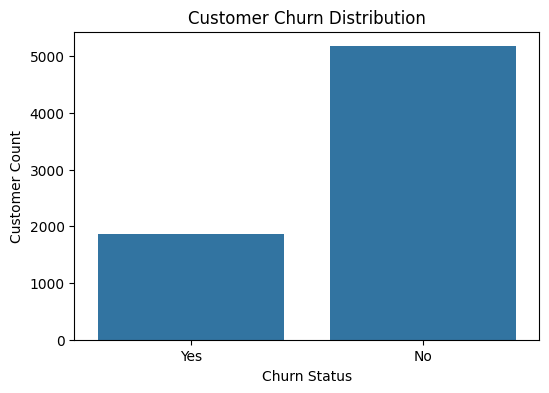

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Churn Label'
)

plt.title('Customer Churn Distribution')

plt.xlabel('Churn Status')
plt.ylabel('Customer Count')

plt.show()

### Observation

The company currently retains the majority of its customers.

Customer Churn Distribution:

- Active Customers: 5,174 (73.46%)
- Churned Customers: 1,869 (26.54%)

Approximately one out of every four customers has discontinued services.

### Insight

While the company maintains a strong retention rate of 73.46%, the churn rate of 26.54% indicates a significant level of customer attrition.

The loss of more than 1,800 customers suggests that there may be underlying issues related to customer experience, pricing, contract structure, service quality, or customer engagement.

### Business Impact

Customer churn directly affects recurring revenue, customer lifetime value, and long-term business growth.

Previous KPI analysis showed that churned customers are associated with approximately $2.86 million in revenue, representing 17.83% of total company revenue.

Reducing churn can therefore have a direct and measurable impact on revenue protection and profitability.

### Hypothesis

Customer churn is unlikely to be evenly distributed across the customer base.

Certain customer segments may be significantly more likely to churn than others based on factors such as:

- Contract Type
- Internet Service Type
- Customer Tenure
- Monthly Charges
- Demographic Characteristics

These relationships will be investigated in the following analyses.

### Recommendation

Identify customer segments with churn rates above the overall company average of 26.54%.

Retention initiatives should focus on the highest-risk customer groups to maximize business impact and improve long-term customer retention.

# Analysis 2: Churn by Gender

## Business Question

Does customer churn vary by gender?

## Why Are We Performing This Analysis?

Understanding whether churn differs across genders helps determine if customer retention behavior is influenced by demographic characteristics.

If meaningful differences exist, the business may consider targeted retention strategies for specific customer groups.

## Business Objective

Compare churn rates between male and female customers.

## Analytical Approach

1. Group customers by Gender.
2. Calculate churn distribution within each gender group.
3. Compare churn percentages.
4. Visualize churn behavior across genders.

## Expected Outcome

Determine whether gender is a significant factor influencing customer churn.

## Metric Used

Churn Rate (%)

In [8]:
gender_churn = pd.crosstab(
    df['Gender'],
    df['Churn Label']
)

gender_churn

Churn Label,No,Yes
Gender,,
Female,2549,939
Male,2625,930


In [9]:
gender_churn_pct = round(
    pd.crosstab(
        df['Gender'],
        df['Churn Label'],
        normalize='index'
    ) * 100,
    2
)

gender_churn_pct

Churn Label,No,Yes
Gender,,
Female,73.08,26.92
Male,73.84,26.16


### Visualization: Churn Rate by Gender

The following chart compares churn behavior between male and female customers.

The visualization helps determine whether gender influences customer retention and whether specific demographic groups require targeted retention strategies.

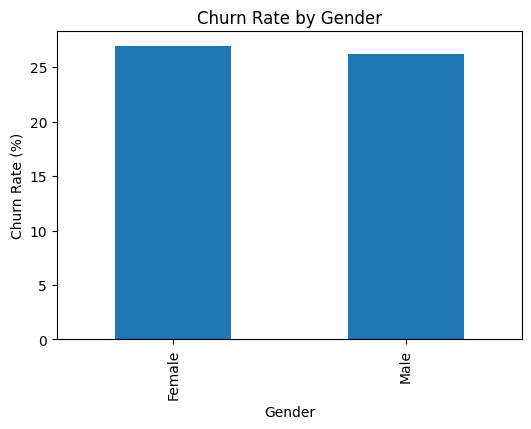

In [10]:
gender_churn_pct['Yes'].plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Churn Rate by Gender')

plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')

plt.show()

### Observation

Customer churn rates are nearly identical across genders.

Churn Rate by Gender:

- Female Customers: 26.92%
- Male Customers: 26.16%

The difference in churn rates is less than one percentage point.

### Insight

Gender does not appear to be a significant driver of customer churn.

Both male and female customers exhibit very similar retention behavior, indicating that customer attrition is likely influenced by other factors rather than gender demographics.

### Business Impact

Since churn rates are nearly identical across genders, gender-based retention campaigns are unlikely to generate meaningful business impact.

Resources should instead be directed toward customer segments that exhibit substantially higher churn risk.

### Hypothesis

Customer churn may be more strongly influenced by factors such as:

- Contract Type
- Internet Service Type
- Customer Tenure
- Monthly Charges
- Payment Method

These factors will be evaluated in subsequent analyses.

### Recommendation

Do not prioritize retention initiatives based solely on gender.

Focus on identifying behavioral, contractual, and service-related characteristics that have a stronger relationship with customer churn.

# Analysis 3: Churn by Senior Citizen Status

## Business Question

Does customer churn differ between senior citizens and non-senior citizens?

## Why Are We Performing This Analysis?

Different age groups often have different service expectations, technology adoption behaviors, pricing sensitivities, and support requirements.

Understanding whether senior citizens churn at different rates can help the business develop targeted retention and customer support strategies.

## Business Objective

Compare churn rates between senior citizen and non-senior citizen customers.

## Analytical Approach

1. Group customers by Senior Citizen status.
2. Calculate churn distribution within each group.
3. Compute churn percentages.
4. Compare retention behavior across customer age segments.

## Expected Outcome

Determine whether senior citizens exhibit higher or lower churn rates compared to non-senior customers.

## Metric Used

Churn Rate (%)

In [11]:
senior_churn = pd.crosstab(
    df['Senior Citizen'],
    df['Churn Label']
)

senior_churn

Churn Label,No,Yes
Senior Citizen,,
No,4508,1393
Yes,666,476


In [12]:
senior_churn_pct = round(
    pd.crosstab(
        df['Senior Citizen'],
        df['Churn Label'],
        normalize='index'
    ) * 100,
    2
)

senior_churn_pct

Churn Label,No,Yes
Senior Citizen,,
No,76.39,23.61
Yes,58.32,41.68


### Visualization: Churn Rate by Senior Citizen Status

The following chart compares churn rates between senior citizen and non-senior citizen customers.

The visualization helps identify whether age-related customer segments exhibit different retention behavior and whether targeted retention initiatives may be required.

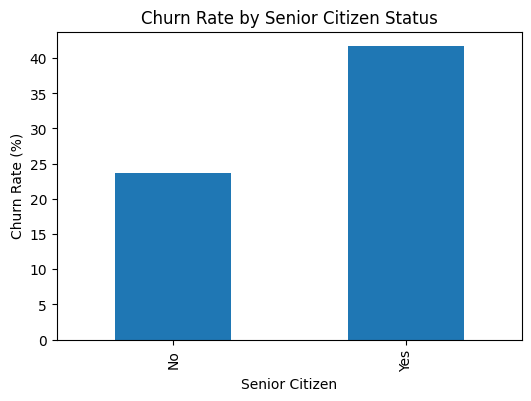

In [13]:
senior_churn_pct['Yes'].plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Churn Rate by Senior Citizen Status')

plt.xlabel('Senior Citizen')
plt.ylabel('Churn Rate (%)')

plt.show()

### Observation

Senior citizen customers exhibit a substantially higher churn rate than non-senior customers.

Churn Rate by Senior Citizen Status:

- Non-Senior Citizens: 23.61%
- Senior Citizens: 41.68%

Senior citizen customers churn at nearly 42%, which is significantly higher than the overall company churn rate of 26.54%.

### Insight

Senior citizens appear to be considerably more likely to discontinue services compared to non-senior customers.

The churn gap of approximately 18 percentage points suggests that age-related factors may influence customer retention behavior.

This is the first customer segment analyzed that demonstrates a meaningful deviation from the overall churn rate.

### Business Impact

Senior citizens represent only 16.21% of the customer base, yet they experience disproportionately high customer attrition.

If retention challenges within this segment remain unaddressed, the company risks continued customer and revenue losses from this vulnerable customer group.

### Hypothesis

Higher churn among senior citizens may be associated with:

- Price sensitivity
- Service complexity
- Customer support experience
- Technology adoption challenges
- Contract preferences

These relationships will be further investigated through contract, tenure, pricing, and service-level churn analyses.

### Recommendation

Develop targeted retention programs for senior citizen customers.

Potential initiatives may include:

- Simplified service plans
- Dedicated customer support
- Loyalty incentives
- Personalized onboarding and education programs

Further analysis should identify the specific factors contributing to elevated churn within this segment.

# Analysis 4: Churn by Contract Type

## Business Question

Does customer churn vary across different contract types?

## Why Are We Performing This Analysis?

Contract duration influences customer commitment and switching behavior.

Customers enrolled in long-term contracts often face higher switching costs and may demonstrate stronger retention compared to customers on flexible month-to-month plans.

Understanding this relationship helps the business identify whether contract structure is a key driver of customer churn.

## Business Objective

Compare churn rates across Month-to-Month, One-Year, and Two-Year contract plans.

## Analytical Approach

1. Group customers by Contract Type.
2. Calculate churn distribution within each contract category.
3. Compute churn percentages.
4. Compare retention behavior across contract durations.

## Expected Outcome

Determine whether contract duration significantly impacts customer churn.

## Metric Used

Churn Rate (%)

In [14]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn Label']
)

contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [15]:
contract_churn_pct = round(
    pd.crosstab(
        df['Contract'],
        df['Churn Label'],
        normalize='index'
    ) * 100,
    2
)

contract_churn_pct

Churn Label,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


### Visualization: Churn Rate by Contract Type

The following chart compares churn rates across different contract types.

The visualization helps determine whether customer commitment levels influence retention behavior and identifies contract segments with elevated churn risk.

Contract duration is often one of the strongest predictors of customer retention because it directly affects customer commitment and switching flexibility.

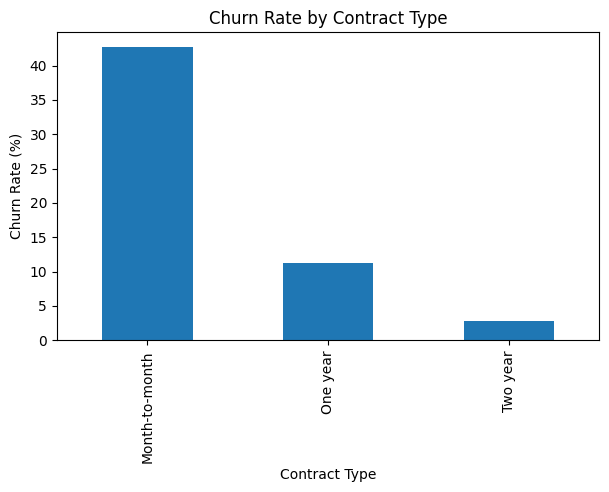

In [16]:
contract_churn_pct['Yes'].plot(
    kind='bar',
    figsize=(7,4)
)

plt.title('Churn Rate by Contract Type')

plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')

plt.show()

### Observation

Customer churn varies significantly across contract types.

Churn Rate by Contract Type:

- Month-to-Month: 42.71%
- One-Year: 11.27%
- Two-Year: 2.83%

Month-to-Month customers exhibit the highest churn rate, while Two-Year contract customers demonstrate exceptionally strong retention.

The churn rate for Month-to-Month customers is more than 15 times higher than that of Two-Year contract customers.

### Insight

Contract type appears to be one of the strongest drivers of customer churn.

Customers enrolled in long-term contracts demonstrate substantially higher retention compared to customers on flexible Month-to-Month plans.

This suggests that customer commitment and contract duration play a critical role in customer retention behavior.

### Business Impact

Month-to-Month customers represent the highest-risk customer segment within the business.

Given that more than half of the customer base is subscribed to Month-to-Month contracts, this segment likely contributes a significant portion of overall customer churn and revenue loss.

Improving retention within this segment could generate a substantial business impact.

### Hypothesis

Higher churn among Month-to-Month customers may be influenced by:

- Lower switching barriers
- Pricing sensitivity
- Service dissatisfaction
- Competitive alternatives
- Lack of long-term commitment incentives

These factors will be further investigated through pricing, tenure, payment method, and service-level churn analyses.

### Recommendation

Prioritize retention initiatives for Month-to-Month customers.

Potential strategies include:

- Contract upgrade incentives
- Loyalty rewards
- Bundled service discounts
- Personalized retention offers
- Early churn intervention programs

Increasing the conversion of Month-to-Month customers into long-term contracts may significantly reduce overall company churn.

# Analysis 5: Churn by Internet Service Type

## Business Question

Does customer churn vary across different internet service types?

## Why Are We Performing This Analysis?

Internet service is one of the company's core offerings and directly influences customer experience, service quality perception, and revenue generation.

Understanding churn behavior across service types helps identify whether specific services are associated with elevated customer attrition.

## Business Objective

Compare churn rates across Fiber Optic, DSL, and customers without internet service.

## Analytical Approach

1. Group customers by Internet Service type.
2. Calculate churn distribution within each service category.
3. Compute churn percentages.
4. Compare retention behavior across service offerings.

## Expected Outcome

Determine whether specific internet services are associated with higher customer churn.

## Metric Used

Churn Rate (%)

In [17]:
internet_churn = pd.crosstab(
    df['Internet Service'],
    df['Churn Label']
)

internet_churn

Churn Label,No,Yes
Internet Service,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [18]:
internet_churn_pct = round(
    pd.crosstab(
        df['Internet Service'],
        df['Churn Label'],
        normalize='index'
    ) * 100,
    2
)

internet_churn_pct

Churn Label,No,Yes
Internet Service,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


### Visualization: Churn Rate by Internet Service Type

The following chart compares churn rates across different internet service categories.

The visualization helps identify whether specific internet services are associated with elevated customer attrition and whether service-related factors may influence customer retention.

Internet service type is a critical business dimension because it directly affects customer experience, service quality perceptions, and recurring revenue generation.

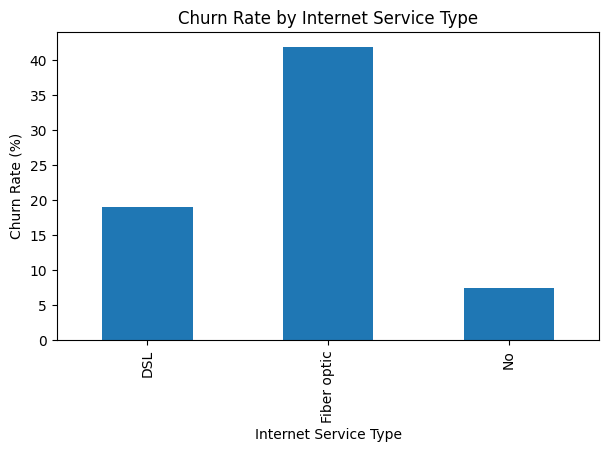

In [19]:
internet_churn_pct['Yes'].plot(
    kind='bar',
    figsize=(7,4)
)

plt.title('Churn Rate by Internet Service Type')

plt.xlabel('Internet Service Type')
plt.ylabel('Churn Rate (%)')

plt.show()

### Observation

Customer churn varies significantly across internet service categories.

Churn Rate by Internet Service Type:

- Fiber Optic: 41.89%
- DSL: 18.96%
- No Internet Service: 7.40%

Fiber Optic customers exhibit the highest churn rate, while customers without internet service demonstrate the strongest retention.

The churn rate among Fiber Optic customers is more than five times higher than customers without internet service.

### Insight

Fiber Optic customers appear to be substantially more likely to discontinue services compared to customers using DSL or customers without internet service.

This finding is particularly important because Fiber Optic represents the company's largest customer segment and highest revenue-generating service category.

The combination of high customer volume, high revenue contribution, and high churn rate makes Fiber Optic customers a critical business segment.

### Business Impact

Fiber Optic customers generate approximately $9.92 million in revenue, making them the company's most valuable service segment.

However, they also experience the highest churn rate at 41.89%.

This suggests that a significant portion of revenue loss may be concentrated within the Fiber Optic customer base.

Reducing churn within this segment could produce a substantial improvement in customer retention and revenue protection.

### Hypothesis

Elevated churn among Fiber Optic customers may be influenced by:

- Higher service pricing
- Customer expectations regarding service quality
- Network performance issues
- Competitive alternatives
- Service reliability concerns

These factors will be further investigated through pricing, tenure, and customer segmentation analyses.

### Recommendation

Prioritize retention efforts for Fiber Optic customers.

Potential strategies include:

- Service quality improvements
- Proactive customer support
- Targeted loyalty programs
- Personalized retention campaigns
- Customer satisfaction monitoring

Further analysis should identify which Fiber Optic customer segments are most likely to churn.

# Analysis 6: Churn by Customer Tenure Group

## Business Question

Does customer churn vary across different tenure groups?

## Why Are We Performing This Analysis?

Customer tenure represents the length of the relationship between the customer and the company.

Customers in the early stages of their journey often exhibit different retention behavior compared to long-term customers.

Understanding churn across tenure groups helps identify critical periods where customers are most likely to leave.

## Business Objective

Compare churn rates across different customer tenure segments.

## Analytical Approach

1. Create customer tenure groups.
2. Calculate churn distribution within each tenure group.
3. Compute churn percentages.
4. Compare retention behavior across customer lifecycle stages.

## Expected Outcome

Identify the tenure periods associated with the highest churn risk.

## Metric Used

Churn Rate (%)

In [20]:
df['Tenure Group'] = pd.cut(
    df['Tenure Months'],
    bins=[0, 12, 24, 48, 72],
    labels=[
        '0-12 Months',
        '13-24 Months',
        '25-48 Months',
        '49-72 Months'
    ],
    include_lowest=True
)

df['Tenure Group'].value_counts()

Tenure Group
49-72 Months    2239
0-12 Months     2186
25-48 Months    1594
13-24 Months    1024
Name: count, dtype: int64

In [21]:
tenure_churn = pd.crosstab(
    df['Tenure Group'],
    df['Churn Label']
)

tenure_churn

Churn Label,No,Yes
Tenure Group,,
0-12 Months,1149,1037
13-24 Months,730,294
25-48 Months,1269,325
49-72 Months,2026,213


In [22]:
tenure_churn_pct = round(
    pd.crosstab(
        df['Tenure Group'],
        df['Churn Label'],
        normalize='index'
    ) * 100,
    2
)

tenure_churn_pct

Churn Label,No,Yes
Tenure Group,,
0-12 Months,52.56,47.44
13-24 Months,71.29,28.71
25-48 Months,79.61,20.39
49-72 Months,90.49,9.51


### Visualization: Churn Rate by Customer Tenure Group

The following chart compares churn rates across different customer tenure groups.

The visualization helps identify critical stages in the customer lifecycle where customers are most likely to discontinue services.

Customer tenure is a key retention metric because it reflects the strength and maturity of the customer relationship with the company.

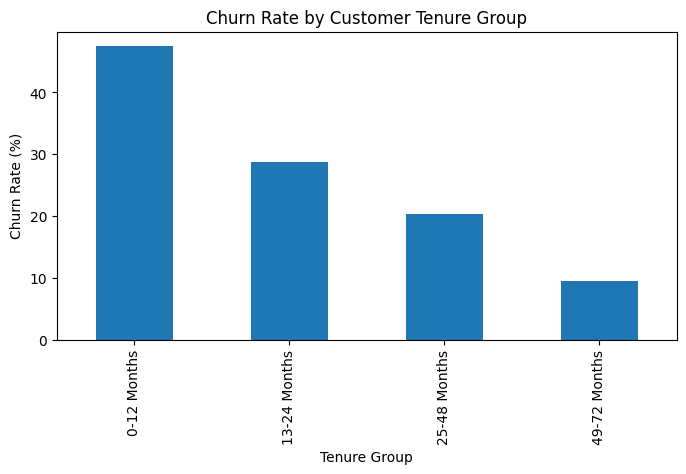

In [23]:
tenure_churn_pct['Yes'].plot(
    kind='bar',
    figsize=(8,4)
)

plt.title('Churn Rate by Customer Tenure Group')

plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')

plt.show()

### Observation

Customer churn decreases significantly as customer tenure increases.

Churn Rate by Tenure Group:

- 0–12 Months: 47.44%
- 13–24 Months: 28.71%
- 25–48 Months: 20.39%
- 49–72 Months: 9.51%

Customers within their first year exhibit the highest churn rate, while long-tenure customers demonstrate substantially stronger retention.

The churn rate among customers in their first 12 months is nearly five times higher than customers with 49–72 months of tenure.

### Insight

Customer tenure appears to be one of the strongest predictors of churn.

Customers who remain with the company for longer periods become increasingly loyal and less likely to discontinue services.

The first 12 months represent the most vulnerable stage of the customer lifecycle and account for a disproportionate share of customer attrition.

### Business Impact

Nearly half of all customers within their first year leave the company.

This indicates that customer acquisition efforts may not be fully translating into long-term customer retention.

Improving retention during the early stages of the customer journey could significantly reduce overall churn and increase customer lifetime value.

### Hypothesis

High churn among newer customers may be influenced by:

- Onboarding experience
- Service quality expectations
- Pricing concerns
- Lack of customer engagement
- Contract flexibility

These factors may contribute to customer dissatisfaction before long-term loyalty is established.

### Recommendation

Prioritize retention efforts during the first 12 months of the customer lifecycle.

Potential initiatives include:

- Enhanced onboarding programs
- Early customer engagement campaigns
- Proactive customer support
- Loyalty incentives
- Customer satisfaction monitoring during the first year

Reducing churn among new customers is likely to produce one of the largest improvements in overall retention performance.

# Analysis 7: Churn by Monthly Charges Group

## Business Question

Does customer churn vary across different monthly charge ranges?

## Why Are We Performing This Analysis?

Monthly Charges represent the recurring amount customers pay for services.

Customers paying higher monthly fees may have different expectations regarding service quality, value, and customer support compared to customers on lower-priced plans.

Understanding the relationship between pricing and churn helps determine whether pricing strategy influences customer retention.

## Business Objective

Compare churn rates across different Monthly Charge segments.

## Analytical Approach

1. Create Monthly Charge groups.
2. Calculate churn distribution within each pricing segment.
3. Compute churn percentages.
4. Compare retention behavior across customer spending levels.

## Expected Outcome

Determine whether higher-paying customers are more likely to churn than lower-paying customers.

## Metric Used

Churn Rate (%)

In [24]:
df['Monthly Charge Group'] = pd.cut(
    df['Monthly Charges'],
    bins=[0, 35, 70, 90, 120],
    labels=[
        'Low ($0-$35)',
        'Medium ($35-$70)',
        'High ($70-$90)',
        'Premium ($90+)'
    ],
    include_lowest=True
)

df['Monthly Charge Group'].value_counts()

Monthly Charge Group
High ($70-$90)      1844
Premium ($90+)      1739
Low ($0-$35)        1735
Medium ($35-$70)    1725
Name: count, dtype: int64

In [25]:
charge_churn = pd.crosstab(
    df['Monthly Charge Group'],
    df['Churn Label']
)

charge_churn

Churn Label,No,Yes
Monthly Charge Group,,
Low ($0-$35),1546,189
Medium ($35-$70),1312,413
High ($70-$90),1147,697
Premium ($90+),1169,570


In [26]:
charge_churn_pct = round(
    pd.crosstab(
        df['Monthly Charge Group'],
        df['Churn Label'],
        normalize='index'
    ) * 100,
    2
)

charge_churn_pct

Churn Label,No,Yes
Monthly Charge Group,,
Low ($0-$35),89.11,10.89
Medium ($35-$70),76.06,23.94
High ($70-$90),62.20,37.80
Premium ($90+),67.22,32.78


### Visualization: Churn Rate by Monthly Charge Group

The following chart compares churn rates across different Monthly Charge segments.

The visualization helps identify whether pricing levels influence customer retention and whether higher-paying customers exhibit elevated churn risk.

Monthly Charges represent recurring customer spending and are closely related to customer value, pricing strategy, and perceived service quality.

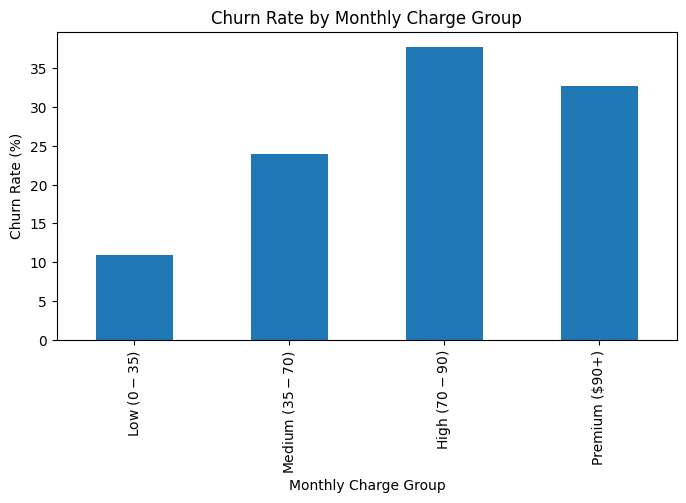

In [27]:
charge_churn_pct['Yes'].plot(
    kind='bar',
    figsize=(8,4)
)

plt.title('Churn Rate by Monthly Charge Group')

plt.xlabel('Monthly Charge Group')
plt.ylabel('Churn Rate (%)')

plt.show()

### Observation

Customer churn increases substantially as monthly charges rise.

Churn Rate by Monthly Charge Group:

- Low ($0-$35): 10.89%
- Medium ($35-$70): 23.94%
- High ($70-$90): 37.80%
- Premium ($90+): 32.78%

Customers in the High ($70-$90) segment exhibit the highest churn rate at 37.80%.

Customers paying lower monthly charges demonstrate significantly stronger retention, with a churn rate of only 10.89%.

### Insight

Customers paying higher monthly charges are considerably more likely to churn than customers on lower-priced plans.

The relationship suggests that pricing, perceived value, or service expectations may influence customer retention behavior.

Although Premium customers pay the highest fees, their churn rate is slightly lower than the High segment, indicating that factors beyond price alone may also affect retention.

### Business Impact

Higher-paying customers contribute a larger share of recurring revenue.

As a result, elevated churn among High and Premium customer segments can have a disproportionately large impact on revenue loss and customer lifetime value.

Reducing churn within these segments could generate substantial financial benefits for the business.

### Hypothesis

Higher churn among customers with elevated monthly charges may be influenced by:

- Price sensitivity
- Perceived lack of value
- Service quality expectations
- Competitive pricing alternatives
- Service dissatisfaction

These factors may contribute to customers questioning whether the service justifies the monthly cost.

### Recommendation

Conduct deeper analysis of high-paying customer segments to understand the primary drivers of churn.

Potential retention strategies include:

- Personalized loyalty incentives
- Service bundle optimization
- Pricing reviews
- Premium customer support
- Targeted retention campaigns

Improving retention among high-value customers should be a strategic priority due to their greater revenue contribution.

# Analysis 8: Churn by Payment Method

## Business Question

Does customer churn vary across different payment methods?

## Why Are We Performing This Analysis?

Payment methods influence customer convenience, billing experience, and service continuity.

Certain payment methods may create friction during the customer journey, increasing the likelihood of customer attrition.

Understanding churn patterns by payment method helps identify operational and billing-related retention opportunities.

## Business Objective

Compare churn rates across different payment methods and identify high-risk payment segments.

## Analytical Approach

1. Group customers by Payment Method.
2. Calculate churn distribution within each payment category.
3. Compute churn percentages.
4. Compare churn behavior across payment methods.

## Expected Outcome

Determine whether specific payment methods are associated with higher customer churn.

## Metric Used

Churn Rate (%)

In [28]:
payment_churn = pd.crosstab(
    df['Payment Method'],
    df['Churn Label']
)

payment_churn

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


In [29]:
payment_churn_pct = round(
    pd.crosstab(
        df['Payment Method'],
        df['Churn Label'],
        normalize='index'
    ) * 100,
    2
)

payment_churn_pct

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


### Visualization: Churn Rate by Payment Method

The following chart compares churn rates across different payment methods.

The visualization helps identify whether billing and payment preferences influence customer retention behavior.

Payment method is an important operational factor because billing convenience, payment reliability, and customer experience can directly impact customer satisfaction and retention.

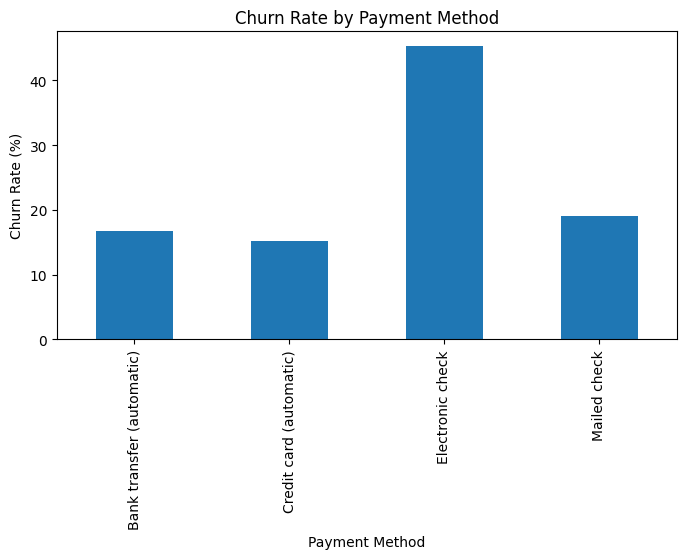

In [30]:
payment_churn_pct['Yes'].plot(
    kind='bar',
    figsize=(8,4)
)

plt.title('Churn Rate by Payment Method')

plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')

plt.show()

### Observation

Customer churn varies significantly across payment methods.

Churn Rate by Payment Method:

- Electronic Check: 45.29%
- Mailed Check: 19.11%
- Bank Transfer (Automatic): 16.71%
- Credit Card (Automatic): 15.24%

Electronic Check customers exhibit the highest churn rate, while customers using automatic payment methods demonstrate the strongest retention.

The churn rate for Electronic Check customers is nearly three times higher than customers using Credit Card Automatic Payments.

### Insight

Payment method appears to be a significant predictor of customer churn.

Customers enrolled in automatic payment methods show substantially lower churn rates compared to customers using Electronic Check payments.

This suggests that convenience, billing experience, and customer commitment may influence retention behavior.

### Business Impact

Electronic Check customers represent a high-risk customer segment and may contribute disproportionately to overall customer attrition.

The large churn gap between Electronic Check users and automatic payment users indicates a potential opportunity to improve retention through billing and payment optimization strategies.

Reducing churn within this segment could significantly improve overall retention performance.

### Hypothesis

Higher churn among Electronic Check customers may be associated with:

- Lower customer commitment
- Billing friction
- Payment inconvenience
- Service cancellation flexibility
- Customer dissatisfaction

These customers may also overlap with other high-risk segments such as Month-to-Month contract customers.

### Recommendation

Encourage customers to migrate from Electronic Check payments to automatic payment methods.

Potential initiatives include:

- Auto-pay enrollment incentives
- Billing discounts
- Loyalty rewards
- Simplified payment setup
- Customer awareness campaigns

Further analysis should evaluate whether Electronic Check customers also belong to other high-risk churn segments.

# Analysis 9: High-Risk Customer Profile Analysis

## Business Question

What characteristics define the customers most likely to churn?

## Why Are We Performing This Analysis?

Previous analyses identified several customer segments with elevated churn rates.

However, customer churn is rarely driven by a single factor.

Combining multiple high-risk characteristics helps identify customer profiles that are most vulnerable to churn and enables the business to develop highly targeted retention strategies.

## Business Objective

Identify the most common characteristics among churned customers and build a high-risk customer profile.

## Analytical Approach

1. Filter churned customers.
2. Analyze key churn drivers identified earlier.
3. Compare the distribution of churned customers across:
   - Contract Type
   - Internet Service
   - Payment Method
   - Tenure Group
4. Identify the dominant churn profile.

## Expected Outcome

Develop a customer profile that represents the highest-risk churn segment.

## Metric Used

Customer Count

Customer Percentage

In [31]:
churned_customers = df[
    df['Churn Label'] == 'Yes'
]

print("Total Churned Customers:", len(churned_customers))

Total Churned Customers: 1869


In [32]:
contract_profile = round(
    churned_customers['Contract']
    .value_counts(normalize=True) * 100,
    2
)

contract_profile

Contract
Month-to-month    88.55
One year           8.88
Two year           2.57
Name: proportion, dtype: float64

In [33]:
internet_profile = round(
    churned_customers['Internet Service']
    .value_counts(normalize=True) * 100,
    2
)

internet_profile

Internet Service
Fiber optic    69.40
DSL            24.56
No              6.05
Name: proportion, dtype: float64

In [34]:
payment_profile = round(
    churned_customers['Payment Method']
    .value_counts(normalize=True) * 100,
    2
)

payment_profile

Payment Method
Electronic check             57.30
Mailed check                 16.48
Bank transfer (automatic)    13.80
Credit card (automatic)      12.41
Name: proportion, dtype: float64

In [35]:
tenure_profile = round(
    churned_customers['Tenure Group']
    .value_counts(normalize=True) * 100,
    2
)

tenure_profile

Tenure Group
0-12 Months     55.48
25-48 Months    17.39
13-24 Months    15.73
49-72 Months    11.40
Name: proportion, dtype: float64

### High-Risk Customer Profile Assessment

The following analysis examines the characteristics most commonly associated with churned customers.

Rather than evaluating individual churn drivers in isolation, this assessment combines multiple dimensions to identify the dominant customer profile among churned customers.

The findings help the business understand which customer segments should be prioritized for retention initiatives.

### Observation

The majority of churned customers share several common characteristics.

Among all churned customers:

#### Contract Type

- Month-to-Month: 88.55%
- One-Year: 8.88%
- Two-Year: 2.57%

#### Internet Service

- Fiber Optic: 69.40%
- DSL: 24.56%
- No Internet Service: 6.05%

#### Payment Method

- Electronic Check: 57.30%
- Mailed Check: 16.48%
- Bank Transfer (Automatic): 13.80%
- Credit Card (Automatic): 12.41%

#### Tenure Group

- 0–12 Months: 55.48%
- 13–24 Months: 15.73%
- 25–48 Months: 17.39%
- 49–72 Months: 11.40%

More than half of all churned customers belong to the first year of their customer lifecycle, while nearly nine out of ten churned customers are enrolled in Month-to-Month contracts.

# Analysis 10: Churn Reason Analysis

## Business Question

What are the most common reasons customers leave the company?

## Why Are We Performing This Analysis?

Understanding why customers churn is essential for designing effective retention strategies.

While previous analyses identified high-risk customer segments, this analysis investigates the specific reasons customers decided to discontinue services.

The findings will help the business prioritize operational improvements and customer retention initiatives.

## Business Objective

Identify the most common churn reasons and determine the primary causes of customer attrition.

## Analytical Approach

1. Analyze churn reasons among churned customers.
2. Calculate frequency and percentage distribution.
3. Identify the most common causes of churn.
4. Recommend business actions based on the findings.

## Expected Outcome

Understand the key business issues driving customer churn and identify actionable retention opportunities.

## Metric Used

Customer Count

Customer Percentage

In [39]:
churn_reason_counts = (
    churned_customers['Churn Reason']
    .value_counts()
)

churn_reason_counts

Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Service dissatisfaction                       89
Lack of self-service on Website               88
Extra data charges                            57
Moved                                         53
Limited range of services                     44
Lack of affordable download/upload speed      44
Long distance charges                         44
Poor expertise of phone support               20
Poor expertise of online support              19
Deceased                                       6
Name: c

In [40]:
churn_reason_pct = round(
    churned_customers['Churn Reason']
    .value_counts(normalize=True) * 100,
    2
)

churn_reason_pct

Churn Reason
Attitude of support person                   10.27
Competitor offered higher download speeds    10.11
Competitor offered more data                  8.67
Don't know                                    8.24
Competitor made better offer                  7.49
Attitude of service provider                  7.22
Competitor had better devices                 6.96
Network reliability                           5.51
Product dissatisfaction                       5.46
Price too high                                5.24
Service dissatisfaction                       4.76
Lack of self-service on Website               4.71
Extra data charges                            3.05
Moved                                         2.84
Limited range of services                     2.35
Lack of affordable download/upload speed      2.35
Long distance charges                         2.35
Poor expertise of phone support               1.07
Poor expertise of online support              1.02
Deceased          

In [41]:
churn_reason_counts.head(10)

Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Name: count, dtype: int64

In [42]:
churn_reason_pct.head(10)

Churn Reason
Attitude of support person                   10.27
Competitor offered higher download speeds    10.11
Competitor offered more data                  8.67
Don't know                                    8.24
Competitor made better offer                  7.49
Attitude of service provider                  7.22
Competitor had better devices                 6.96
Network reliability                           5.51
Product dissatisfaction                       5.46
Price too high                                5.24
Name: proportion, dtype: float64

### Visualization: Top Churn Reasons

The following chart displays the most common reasons customers discontinued services.

The visualization helps identify the primary business issues contributing to customer churn and highlights areas where retention initiatives may have the greatest impact.

Understanding churn reasons enables the business to move beyond identifying high-risk customers and focus on addressing the root causes of customer attrition.

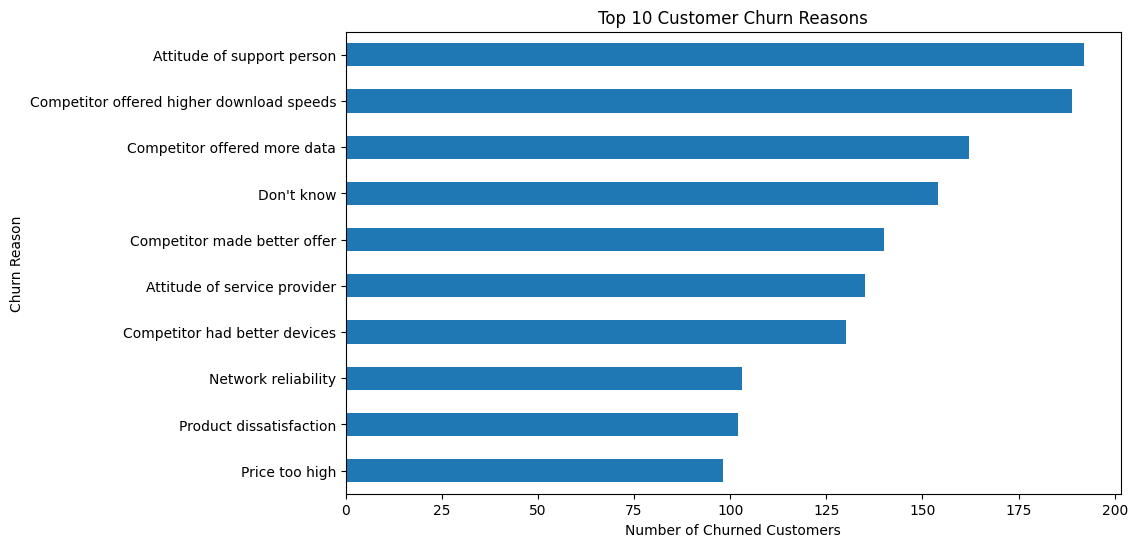

In [43]:
churn_reason_counts.head(10).sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Top 10 Customer Churn Reasons')

plt.xlabel('Number of Churned Customers')
plt.ylabel('Churn Reason')

plt.show()

### Observation

Customer churn is driven by a combination of competitive pressures, customer service issues, product dissatisfaction, and pricing concerns.

Top Churn Reasons:

1. Attitude of Support Person (192 customers, 10.27%)
2. Competitor Offered Higher Download Speeds (189 customers, 10.11%)
3. Competitor Offered More Data (162 customers, 8.67%)
4. Don't Know (154 customers, 8.24%)
5. Competitor Made Better Offer (140 customers, 7.49%)
6. Attitude of Service Provider (135 customers, 7.22%)
7. Competitor Had Better Devices (130 customers, 6.96%)
8. Network Reliability (103 customers, 5.51%)
9. Product Dissatisfaction (102 customers, 5.46%)
10. Price Too High (98 customers, 5.24%)

Customer service-related issues and competitor-related factors collectively account for a substantial share of total churn.

### Insight

The analysis suggests that customer churn is not driven by a single factor.

Three major themes emerge:

#### 1. Competitive Pressure

Customers are leaving because competitors provide:

- Higher download speeds
- More data
- Better offers
- Better devices

This indicates that competitive positioning is a significant challenge for the business.

#### 2. Customer Experience Issues

The most common churn reason is Attitude of Support Person.

Combined with Attitude of Service Provider, customer experience concerns account for a significant portion of churn.

This suggests that service interactions may be negatively impacting customer retention.

#### 3. Product and Pricing Concerns

Network reliability issues, product dissatisfaction, and pricing concerns indicate potential gaps in service quality and value perception.

Customers may not feel they are receiving sufficient value for the price they pay.

### Business Impact

The churn reasons identified in this analysis align closely with the high-risk customer segments identified earlier.

Customers using Fiber Optic services, Month-to-Month contracts, Electronic Check payments, and those within their first year of tenure may be particularly sensitive to:

- Competitive alternatives
- Service quality concerns
- Customer support experiences
- Pricing and value perception

Failure to address these issues may result in continued customer attrition and recurring revenue loss.

### Recommendation

To reduce customer churn, the business should prioritize the following initiatives:

#### Improve Customer Support Experience

- Enhance customer service training
- Improve issue resolution processes
- Monitor customer satisfaction scores

#### Strengthen Competitive Positioning

- Review pricing and service offerings
- Improve download speeds and data packages
- Evaluate competitive market offerings regularly

#### Improve Service Quality

- Address network reliability concerns
- Improve service stability and performance

#### Enhance Customer Retention Programs

- Target high-risk customer segments
- Implement proactive retention campaigns
- Offer personalized loyalty incentives

Reducing churn requires a combination of operational improvements, service enhancements, and customer-centric retention strategies.

# Executive Summary

## Key Findings

1. Overall Churn Rate: 26.54%

2. Highest-Risk Customer Segments:
   - Month-to-Month Customers (42.71%)
   - Fiber Optic Customers (41.89%)
   - Senior Citizens (41.68%)
   - Customers with 0–12 Months Tenure (47.44%)
   - Electronic Check Users (45.29%)

3. High-Risk Customer Profile:
   - Month-to-Month Contract
   - Fiber Optic Service
   - Electronic Check Payment
   - First 12 Months of Tenure

4. Top Churn Reasons:
   - Attitude of Support Person
   - Competitor Higher Download Speeds
   - Competitor More Data
   - Competitor Better Offers
   - Network Reliability Issues

## Strategic Recommendations

- Improve customer support experience
- Strengthen onboarding during the first year
- Encourage migration to long-term contracts
- Improve Fiber Optic service quality
- Promote automatic payment methods
- Enhance competitive pricing and service offerings

## Expected Business Impact

Implementing targeted retention strategies for high-risk customer segments can reduce churn, increase customer lifetime value, and protect recurring revenue.